<a href="https://colab.research.google.com/github/Wilhelm-Muller/portfolio-risk-analysis/blob/main/portfolio_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import yfinance as yf

# Define your portfolio and timeframe
assets = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
data = yf.download(assets, start='2023-01-01')
data = data['Close']

returns = data.pct_change()
returns


/tmp/ipykernel_2467/3031143945.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start='2023-01-01')
[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2023-01-03,NaN,NaN,NaN,NaN
2023-01-04,0.010314,-0.007924,-0.011670,-0.043743
2023-01-05,-0.010605,-0.023726,-0.021344,-0.029638
2023-01-06,0.036794,0.035611,0.013225,0.011785
2023-01-09,0.004089,0.014870,0.007786,0.009736
...,...,...,...,...
2026-03-02,0.002044,-0.007667,-0.016808,0.014793
2026-03-03,-0.003664,0.001632,-0.009592,0.013499
2026-03-04,-0.004664,0.038758,-0.001482,0.003144


In [9]:
# 1. Annualized Return
annual_return = returns.mean() * 252

# 2. Annualized Volatility
annual_volatility = returns.std() * np.sqrt(252)

# 3. Sharpe Ratio
risk_free_rate = 0.03  # Assuming a 3% risk-free rate
sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility

# Consolidate into a nice table
stats = pd.DataFrame({
    'Annual Return': annual_return,
    'Annual Volatility': annual_volatility,
    'Sharpe Ratio': sharpe_ratio
})

print(stats)

        Annual Return  Annual Volatility  Sharpe Ratio
Ticker                                                
AAPL         0.266621           0.256514      0.922449
AMZN         0.339462           0.319546      0.968443
GOOGL        0.430357           0.298800      1.339885
MSFT         0.206887           0.241459      0.732577


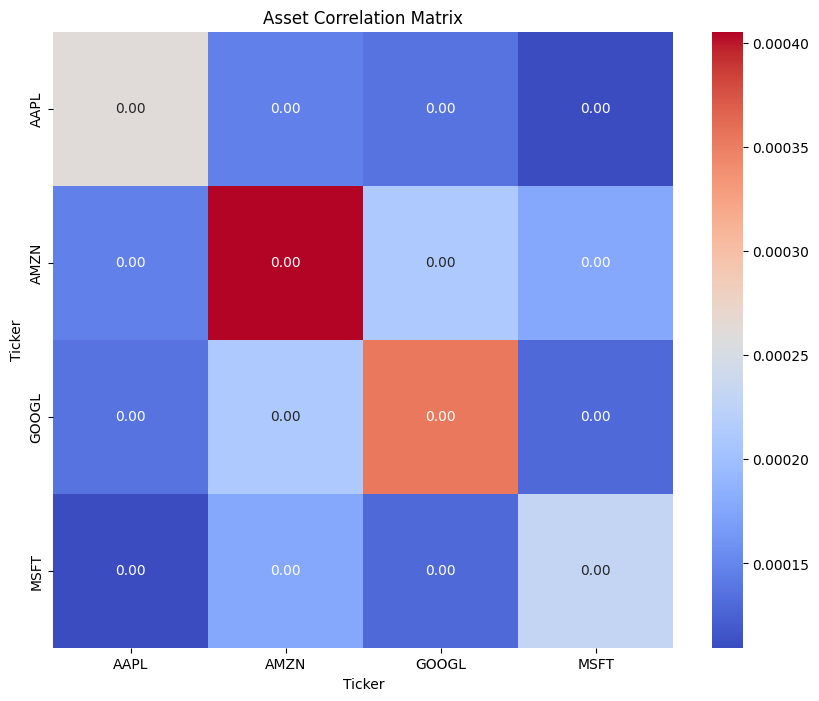

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
cov_matrix = returns.cov()
corr_matrix = returns.corr()

# Visualize it with a Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Asset Correlation Matrix')
plt.show()

In [11]:
from scipy.optimize import minimize
# Define objective function
def get_portfolio_stats(weights, mean_returns, cov_matrix):
    # Annualized portfolio performance
    p_ret = np.sum(weights * mean_returns)
    p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    p_sharpe = (p_ret - 0.03) / p_vol # 3% Risk-free rate
    return p_ret, p_vol, p_sharpe

# The function we want Scipy to minimize
def min_func_sharpe(weights, mean_returns, cov_matrix):
    return -get_portfolio_stats(weights, mean_returns, cov_matrix)[2]

In [12]:
# Constraint: The sum of weights is 1
# 'type': 'eq' means it must equal zero. So sum(x) - 1 = 0
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Bounds: Each weight is between 0 and 1
num_assets = len(assets)
bounds = tuple((0, 1) for _ in range(num_assets))

# Initial Guess: Equal distribution
init_guess = num_assets * [1. / num_assets]

# Run the optimizer
opt_results = minimize(min_func_sharpe,
                       init_guess,
                       args=(annual_return, cov_matrix),
                       method='SLSQP',
                       bounds=bounds,
                       constraints=constraints)

# Extracting the results
optimal_weights = opt_results.x
opt_ret, opt_vol, opt_sharpe = get_portfolio_stats(optimal_weights, annual_return, cov_matrix)

print("--- Optimal Portfolio (Max Sharpe) ---")
for stock, weight in zip(assets, optimal_weights):
    print(f"{stock}: {weight:.2%}")
print(f"\nExpected Return: {opt_ret:.2%}")
print(f"Volatility: {opt_vol:.2%}")
print(f"Max Sharpe Ratio: {opt_sharpe:.2f}")

--- Optimal Portfolio (Max Sharpe) ---
AAPL: 24.14%
MSFT: 12.49%
GOOGL: 63.36%
AMZN: 0.00%

Expected Return: 37.95%
Volatility: 1.57%
Max Sharpe Ratio: 22.20


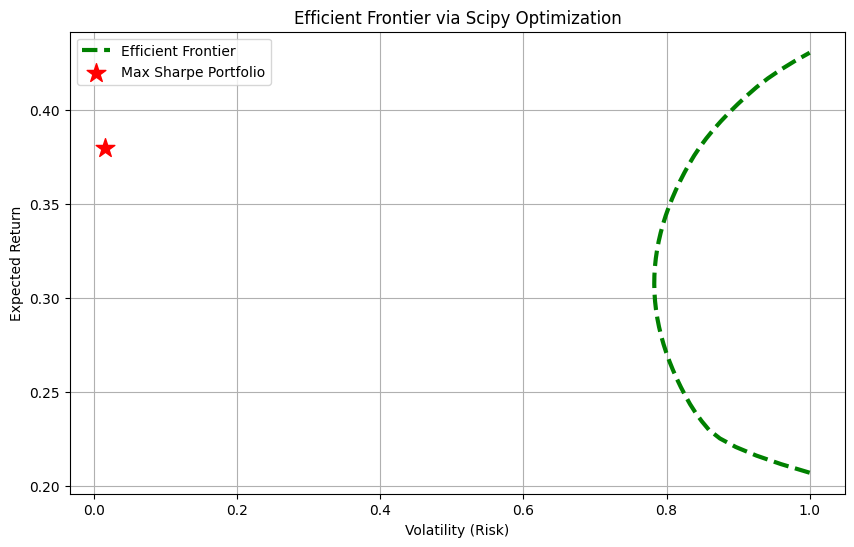

In [14]:
# Finding efficient frontier
# Create a range of target returns
target_returns = np.linspace(annual_return.min(), annual_return.max(), 50)
target_volatilities = []

def min_func_volatility(weights, mean_returns, cov_matrix):
    return get_portfolio_stats(weights, mean_returns, cov_matrix)[1]

for target in target_returns:
    cons = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
            {'type': 'eq', 'fun': lambda x: get_portfolio_stats(x, annual_return, cov_matrix)[0] - target})

    res = minimize(min_func_volatility, init_guess, args=(annual_return, corr_matrix),
                   method='SLSQP', bounds=bounds, constraints=cons)
    target_volatilities.append(res.fun)

plt.figure(figsize=(10, 6))
plt.plot(target_volatilities, target_returns, 'g--', linewidth=3, label='Efficient Frontier')
plt.scatter(opt_vol, opt_ret, color='red', marker='*', s=200, label='Max Sharpe Portfolio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier via Scipy Optimization')
plt.legend()
plt.grid(True)
plt.show()